In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
loan_data=pd.read_csv("loan_data.csv")
print(loan_data.head())

   credit.policy             purpose  int.rate  installment  log.annual.inc  \
0              1  debt_consolidation    0.1189       829.10       11.350407   
1              1         credit_card    0.1071       228.22       11.082143   
2              1  debt_consolidation    0.1357       366.86       10.373491   
3              1  debt_consolidation    0.1008       162.34       11.350407   
4              1         credit_card    0.1426       102.92       11.299732   

     dti  fico  days.with.cr.line  revol.bal  revol.util  inq.last.6mths  \
0  19.48   737        5639.958333      28854        52.1               0   
1  14.29   707        2760.000000      33623        76.7               0   
2  11.63   682        4710.000000       3511        25.6               1   
3   8.10   712        2699.958333      33667        73.2               1   
4  14.97   667        4066.000000       4740        39.5               0   

   delinq.2yrs  pub.rec  not.fully.paid  
0            0        0   

In [2]:
loan_data.duplicated().sum()

np.int64(0)

In [3]:
loan_data.isnull().sum()

,0
credit.policy,0
purpose,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0


In [4]:
loan_data.isna().sum()

,0
credit.policy,0
purpose,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0


In [5]:
loan_data.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [6]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


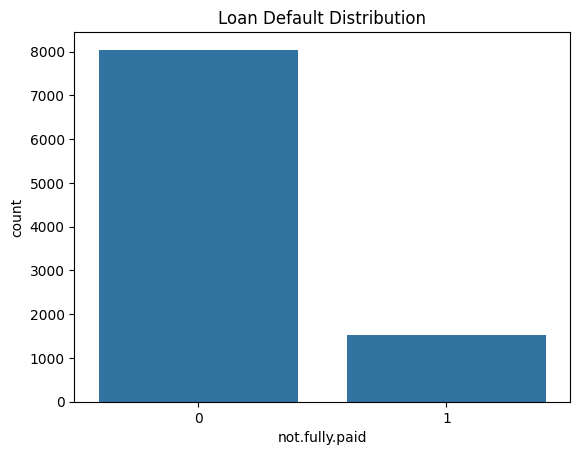

In [7]:
sns.countplot(x='not.fully.paid', data=loan_data)
plt.title("Loan Default Distribution")
plt.show()

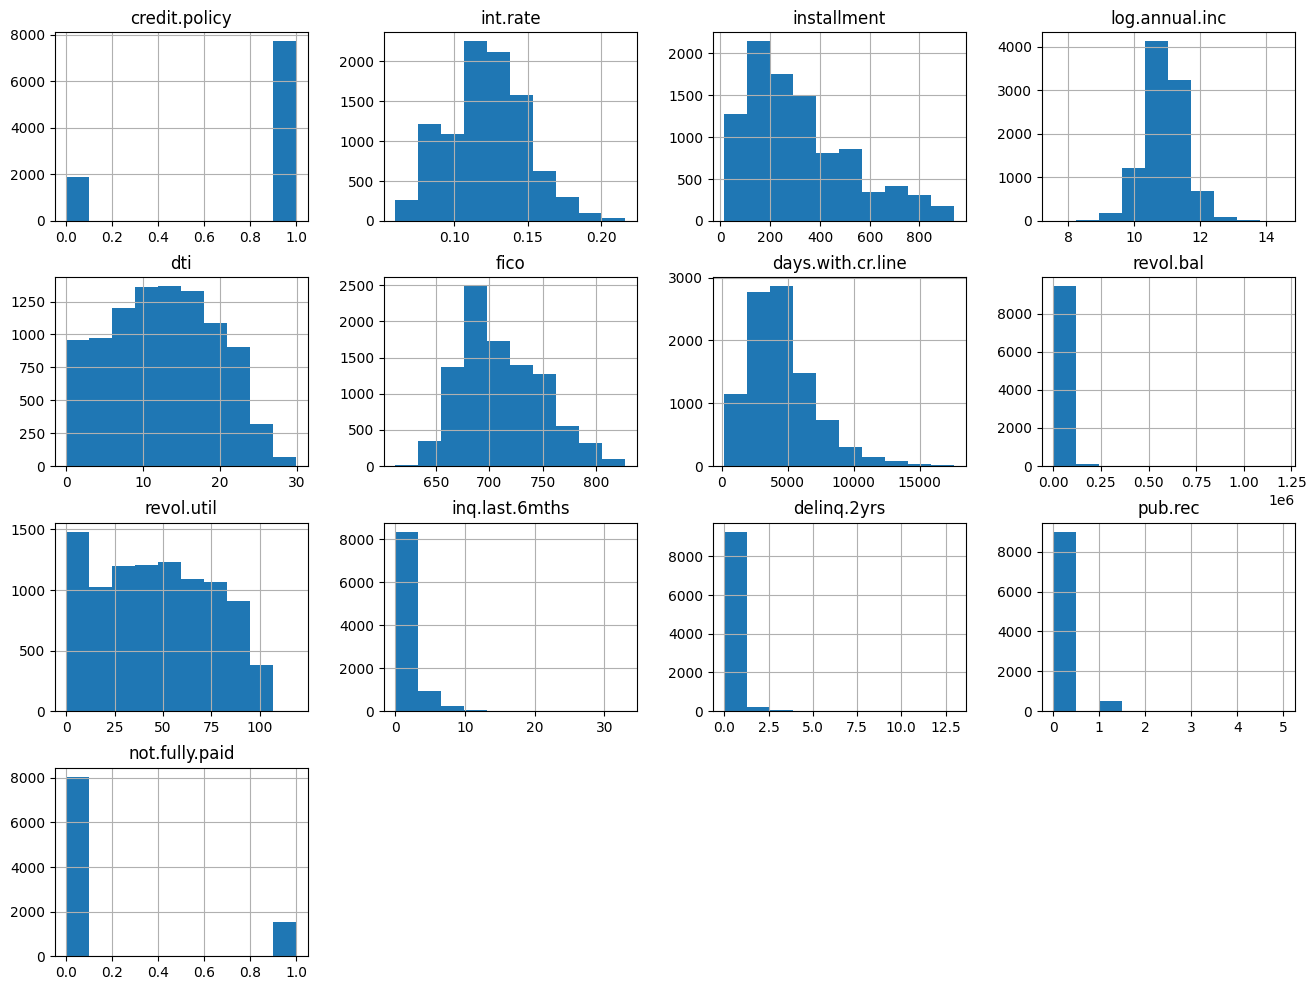

In [8]:
loan_data.hist(figsize=(16,12))
plt.show()

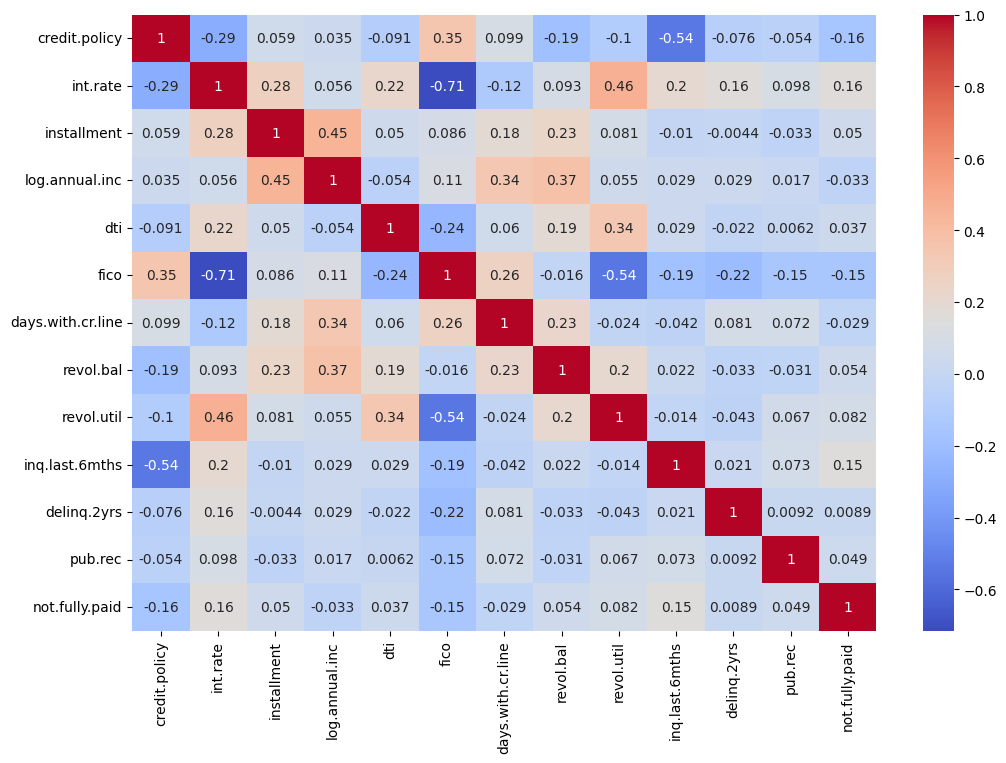

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(
    loan_data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.show()

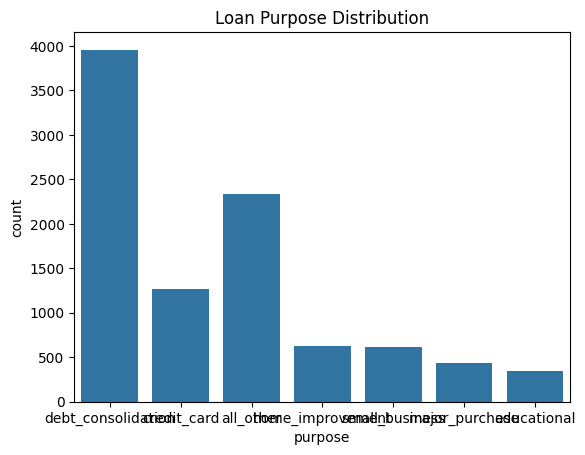

In [10]:
sns.countplot(x='purpose', data=loan_data)
plt.title("Loan Purpose Distribution")
plt.show()

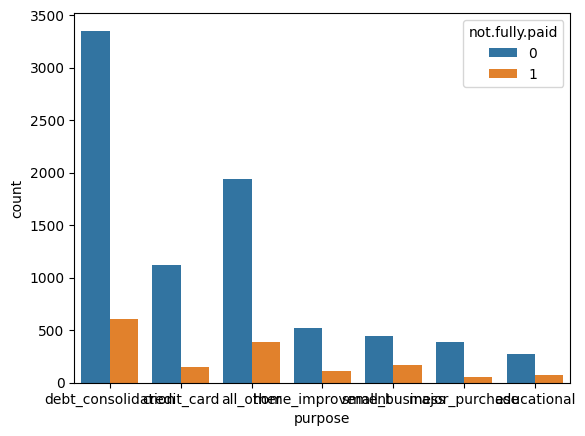

In [11]:
sns.countplot(x='purpose',hue='not.fully.paid',data=loan_data)
plt.show()

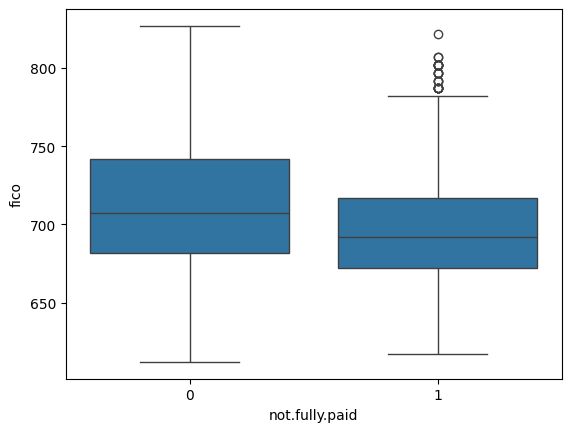

In [12]:
sns.boxplot(x='not.fully.paid',y='fico',data=loan_data)
plt.xticks()
plt.show()

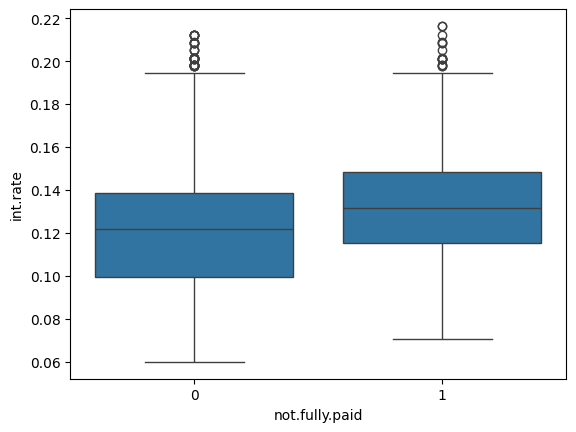

In [13]:
sns.boxplot(x='not.fully.paid',y='int.rate',data=loan_data)
plt.show()

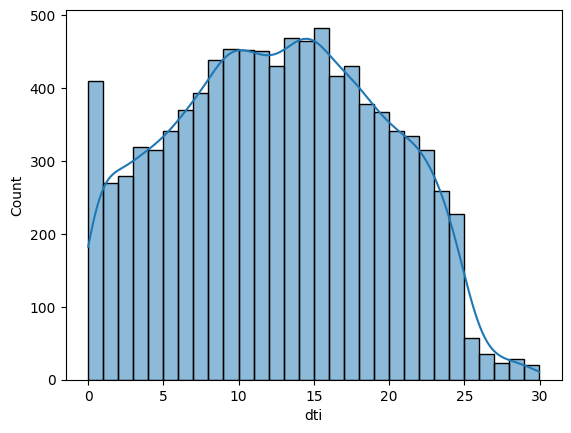

In [14]:
sns.histplot(loan_data["dti"], kde=True)
plt.show()

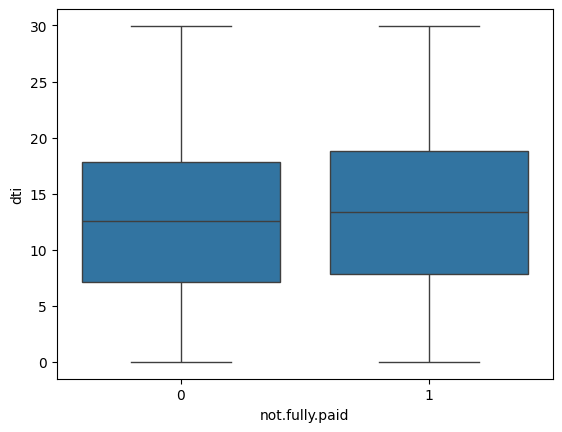

In [15]:
sns.boxplot(y="dti", x="not.fully.paid", data=loan_data)
plt.show()

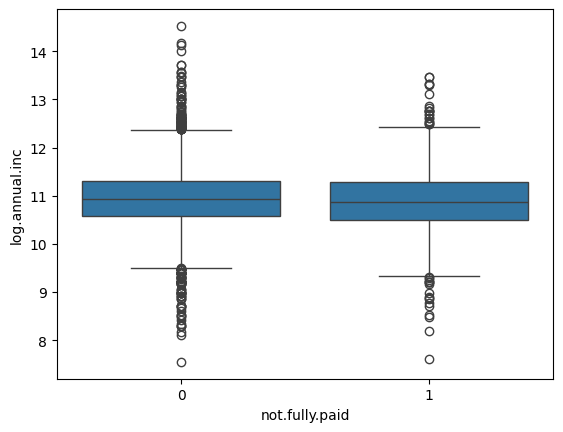

In [16]:
sns.boxplot(y="log.annual.inc", x="not.fully.paid", data=loan_data)
plt.show()

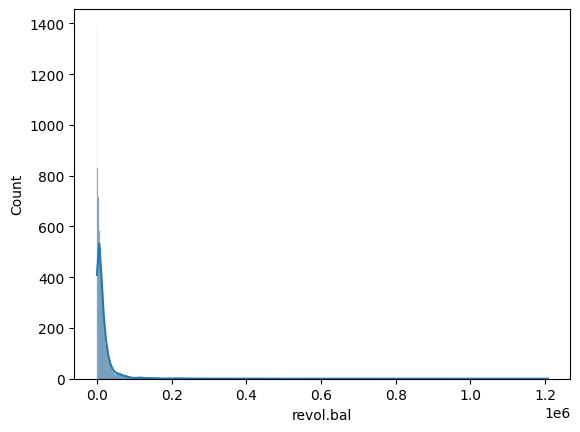

In [17]:
sns.histplot(loan_data["revol.bal"],kde=True)
plt.show()

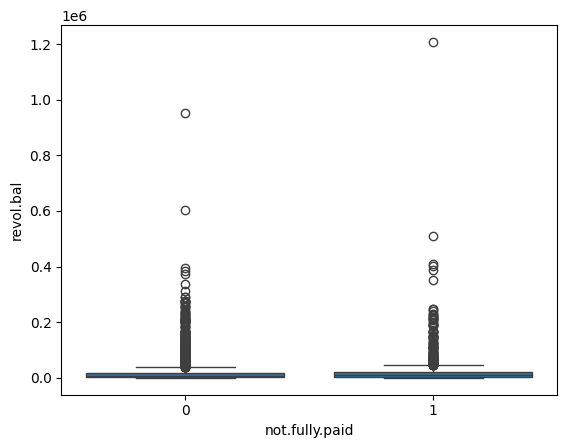

In [18]:
sns.boxplot(y="revol.bal", x="not.fully.paid", data=loan_data)
plt.show()

In [19]:
loan_data["not.fully.paid"].value_counts()

,count
not.fully.paid,
0,8045
1,1533


In [20]:
cate_col = loan_data.select_dtypes(include="object")
print(cate_col)

                 purpose
0     debt_consolidation
1            credit_card
2     debt_consolidation
3     debt_consolidation
4            credit_card
...                  ...
9573           all_other
9574           all_other
9575  debt_consolidation
9576    home_improvement
9577  debt_consolidation

[9578 rows x 1 columns]


In [21]:
dummy= pd.get_dummies(cate_col).astype(int)
dummy

,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,0,0,1,0,0,0,0
1,0,1,0,0,0,0,0
2,0,0,1,0,0,0,0
3,0,0,1,0,0,0,0
4,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...
9573,1,0,0,0,0,0,0
9574,1,0,0,0,0,0,0
9575,0,0,1,0,0,0,0
9576,0,0,0,0,1,0,0


In [22]:
loan_data=pd.concat([loan_data,dummy],axis=1)
loan_data = loan_data.drop("purpose", axis=1)

In [23]:
loan_data.isnull().sum()

,0
credit.policy,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0
inq.last.6mths,0


In [24]:
x_train, x_test, y_train, y_test = train_test_split(
    loan_data.drop('not.fully.paid', axis=1),
    loan_data['not.fully.paid'],
    test_size=0.2,
    random_state=42,stratify=loan_data['not.fully.paid']
)

In [25]:
x_train

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
6381,1,0.1426,548.90,11.362103,12.71,687,5264.041667,16799,74.7,1,1,0,0,1,0,0,0,0,0
7589,1,0.0751,155.55,11.041321,12.75,737,5160.000000,11757,42.6,0,0,0,0,1,0,0,0,0,0
465,1,0.0983,136.00,10.778956,11.93,717,6329.041667,19708,37.1,0,1,0,0,0,1,0,0,0,0
5343,1,0.1357,339.69,11.608236,16.12,687,3330.000000,1584,49.5,1,0,0,1,0,0,0,0,0,0
8016,0,0.1312,438.78,11.654425,10.33,662,660.000000,0,0.0,4,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8576,0,0.1071,58.69,11.719940,11.55,682,4950.000000,15853,63.4,6,0,0,0,1,0,0,0,0,0
4225,1,0.1114,492.06,11.097410,13.98,752,7260.000000,17312,68.4,2,0,0,0,0,0,0,1,0,0
2876,1,0.0768,249.53,10.819778,11.59,722,2130.000000,9287,27.9,2,0,0,0,0,1,0,0,0,0
3170,1,0.1189,505.76,11.407565,9.44,737,3029.958333,5137,24.2,0,0,0,0,0,0,0,0,0,1


In [26]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_sm,y_train_sm=smote.fit_resample(x_train,y_train)

In [27]:
x_train.shape

(7662, 19)

In [28]:
y_train.shape

(7662,)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_sc=scaler.fit_transform(x_train_sm)
x_test_sc=scaler.transform(x_test)

In [30]:
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow import keras
from tensorflow.keras.models import Sequential
def build_model():
  model = Sequential([
      Input(shape=(x_train_sc.shape[1],)),
      Dense(64, activation='relu'),
      Dense(32, activation='relu'),
      Dropout(0.3),
      Dense(16, activation='relu'),
      Dense(1, activation='sigmoid')
  ])
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [31]:
model=build_model()

In [32]:
early_stop=keras.callbacks.EarlyStopping(monitor='val_loss',patience=10)

In [33]:
import numpy as np
model = build_model()
history=model.fit(x_train_sc.astype(np.float32), y_train_sm.astype(np.float32), epochs=100, batch_size=32, validation_split=0.2, callbacks=early_stop)

Epoch 1/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7502 - loss: 0.5194 - val_accuracy: 0.8062 - val_loss: 0.3528
Epoch 2/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8097 - loss: 0.4233 - val_accuracy: 0.7410 - val_loss: 0.3095
Epoch 3/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8145 - loss: 0.4111 - val_accuracy: 0.7938 - val_loss: 0.2843
Epoch 4/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8117 - loss: 0.4077 - val_accuracy: 0.7503 - val_loss: 0.3183
Epoch 5/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8203 - loss: 0.3983 - val_accuracy: 0.8167 - val_loss: 0.2508
Epoch 6/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8188 - loss: 0.3987 - val_accuracy: 0.8062 - val_loss: 0.2654
Epoch 7/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8224 - loss: 0.3926 - val_accuracy: 0.7911 - val_loss: 0.2880
Epoch 8/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8224 - loss: 0.3933 - val_accu

In [34]:
hist=pd.DataFrame(history.history)
hist['epoch']=history.epoch
hist.tail()

,accuracy,loss,val_accuracy,val_loss,epoch
59,0.864135,0.314447,0.857476,0.209449,59
60,0.863553,0.315984,0.871068,0.198688,60
61,0.862096,0.316798,0.850097,0.233002,61
62,0.863941,0.316089,0.868738,0.195660,62
63,0.865883,0.312142,0.866019,0.205391,63


In [35]:
y_test_pred=model.predict(x_test_sc)
y_test_pred=(y_test_pred>0.5).astype(int)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [36]:
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
conf_mat=confusion_matrix(y_test,y_test_pred)
recall_scr=recall_score(y_test,y_test_pred)
acc_score=accuracy_score(y_test,y_test_pred)
print(f"Recall Score: {recall_scr}")
print(f"Accuracy Score: {acc_score}")

Recall Score: 0.13680781758957655
Accuracy Score: 0.7969728601252609


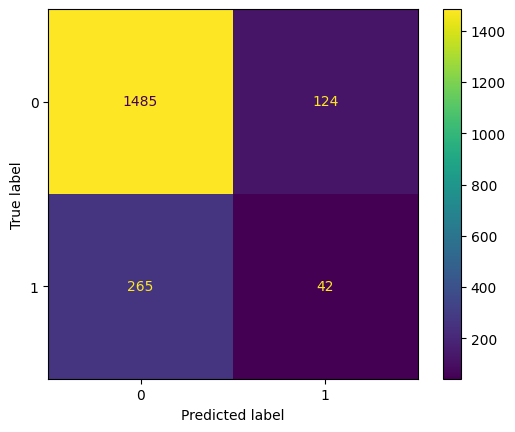

In [37]:
conf_mat=confusion_matrix(y_test, y_test_pred)
conf_dis=ConfusionMatrixDisplay(confusion_matrix=conf_mat)
conf_dis.plot()

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score
y_test_prob=model.predict(x_test_sc)
fpr, tpr, thresholds=roc_curve(y_test, y_test_prob)
auc = roc_auc_score(y_test, y_test_prob)
print(f"AUC: {auc}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
AUC: 0.6219565028149883


Text(0.5, 1.0, 'ROC Curve')

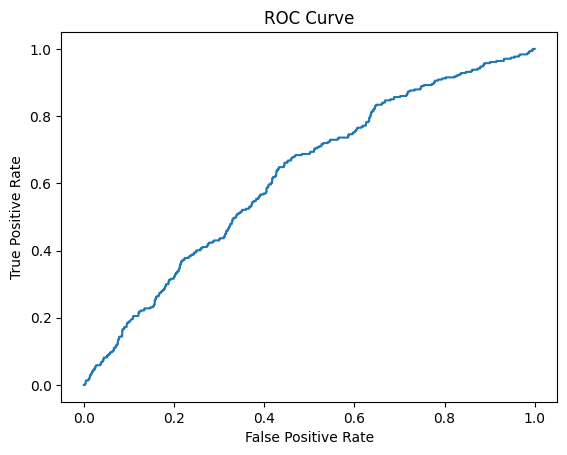

In [39]:
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")